# 🎲 Naive Bayes

The most direct application of the Math Refresher's Bayes' theorem in this entire series — Naive Bayes computes $P(\text{class} \mid \text{features})$ using exactly the prior × likelihood / evidence formula from that notebook, class by class, prediction by prediction.

📖 Full mathematical explanation (Bayes' theorem recap, the naive assumption, Gaussian/Multinomial/Bernoulli variants, Laplace smoothing): [README.md](README.md)


## 1. Setup & Recap — Bayes' Theorem

The Math Refresher's disease-test example computed $P(\text{Disease} \mid \text{Positive test})$ from a prior and a likelihood. Naive Bayes does exactly this, once per class, to classify a new example.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import make_classification, load_wine
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer


In [2]:
sns.set_theme(style="whitegrid")
np.random.seed(42)


In [3]:
# Recap: Bayes' theorem applied to a classification-style question
p_spam = 0.3                      # P(class = spam) -- prior
p_word_given_spam = 0.8           # P(contains "free" | spam) -- likelihood
p_word_given_not_spam = 0.05      # P(contains "free" | not spam)


In [4]:
p_word = p_word_given_spam * p_spam + p_word_given_not_spam * (1 - p_spam)
p_spam_given_word = (p_word_given_spam * p_spam) / p_word


In [5]:
print(f"P(word 'free' appears)        = {p_word:.4f}")
print(f"P(spam | contains 'free')     = {p_spam_given_word:.4f}")
print("-> This exact prior x likelihood / evidence computation, repeated per class, IS Naive Bayes.")


P(word 'free' appears)        = 0.2750
P(spam | contains 'free')     = 0.8727
-> This exact prior x likelihood / evidence computation, repeated per class, IS Naive Bayes.


## 2. The "Naive" Independence Assumption

Real features are almost never truly independent given the class. Naive Bayes assumes they are anyway — an approximation, not a fact about the data — because it makes the math (and the computation) tractable, and often still works well in practice.


In [6]:
# Demonstrate: the naive assumption factorizes a joint likelihood into a product of per-feature likelihoods
# P(x1, x2 | C) = P(x1 | C) * P(x2 | C)   <-- ASSUMED, not derived


In [7]:
np.random.seed(1)
feature_1 = np.random.normal(0, 1, 1000)
feature_2 = feature_1 * 0.9 + np.random.normal(0, 0.3, 1000)   # feature_2 strongly correlated with feature_1


In [8]:
correlation = np.corrcoef(feature_1, feature_2)[0, 1]
print(f"Correlation between feature_1 and feature_2: {correlation:.3f}")
print("-> Naive Bayes will treat these as independent anyway -- a real violation of its core assumption,")
print("   revisited in section 16 to see how much it actually hurts accuracy.")


Correlation between feature_1 and feature_2: 0.945
-> Naive Bayes will treat these as independent anyway -- a real violation of its core assumption,
   revisited in section 16 to see how much it actually hurts accuracy.


## 3. Gaussian Naive Bayes — the Model

For continuous features, GaussianNB assumes each feature is Normally distributed *within each class* (tying directly to the Math Refresher's Normal distribution section). Formula and full derivation in the README.


In [9]:
X_2d, y_2d = make_classification(
    n_samples=300, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.5, random_state=42
)


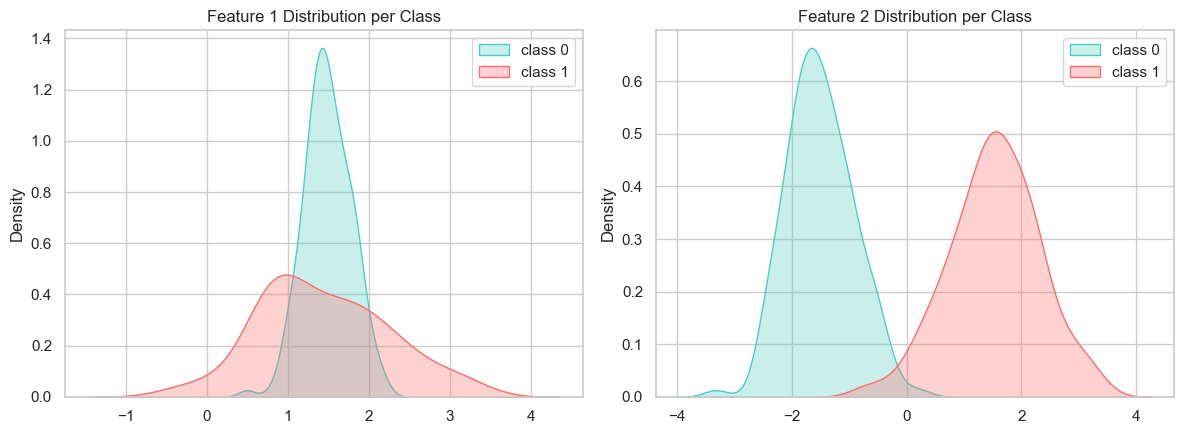

-> GaussianNB fits one Normal curve like these per feature, per class, then multiplies them together.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for cls, color in zip([0, 1], ["#4ecdc4", "#ff6b6b"]):
    sns.kdeplot(X_2d[y_2d == cls, 0], ax=axes[0], color=color, label=f"class {cls}", fill=True, alpha=0.3)
    sns.kdeplot(X_2d[y_2d == cls, 1], ax=axes[1], color=color, label=f"class {cls}", fill=True, alpha=0.3)
axes[0].set_title("Feature 1 Distribution per Class")
axes[1].set_title("Feature 2 Distribution per Class")
axes[0].legend(); axes[1].legend()
plt.tight_layout()
plt.show()
print("-> GaussianNB fits one Normal curve like these per feature, per class, then multiplies them together.")


## 4. From-Scratch Gaussian Naive Bayes

Implementing the full training + prediction pipeline: estimate each class's prior, each feature's per-class mean/variance, then classify new points using the Gaussian PDF (Math Refresher's normal distribution formula) plugged directly into Bayes' theorem.


In [11]:
def fit_gaussian_nb(X, y):
    classes = np.unique(y)
    params = {}
    for c in classes:
        X_c = X[y == c]
        params[c] = {
            "prior": len(X_c) / len(X),
            "mean": X_c.mean(axis=0),
            "var": X_c.var(axis=0) + 1e-9,   # tiny epsilon avoids division by zero
        }
    return params


In [12]:
def gaussian_pdf(x, mean, var):
    return (1 / np.sqrt(2 * np.pi * var)) * np.exp(-((x - mean) ** 2) / (2 * var))


In [13]:
def predict_gaussian_nb(X, params):
    predictions = []
    for x in X:
        class_scores = {}
        for c, p in params.items():
            likelihood = np.prod(gaussian_pdf(x, p["mean"], p["var"]))   # the "naive" independence assumption in action
            class_scores[c] = p["prior"] * likelihood
        predictions.append(max(class_scores, key=class_scores.get))
    return np.array(predictions)


In [14]:
nb_params = fit_gaussian_nb(X_2d, y_2d)
scratch_preds = predict_gaussian_nb(X_2d, nb_params)
print("From-scratch training accuracy:", round(accuracy_score(y_2d, scratch_preds), 4))
for c, p in nb_params.items():
    print(f"\nClass {c}: prior={p['prior']:.3f}, mean={p['mean'].round(3)}, var={p['var'].round(3)}")


From-scratch training accuracy: 0.9833

Class 0: prior=0.500, mean=[ 1.49  -1.511], var=[0.081 0.328]

Class 1: prior=0.500, mean=[1.446 1.525], var=[0.653 0.614]


## 5. Comparing Against scikit-learn

Verifying the from-scratch model against `GaussianNB` — should match closely, since both estimate the same per-class Gaussian parameters from the same data.


In [15]:
sklearn_gnb = GaussianNB()
sklearn_gnb.fit(X_2d, y_2d)
sklearn_preds = sklearn_gnb.predict(X_2d)


In [16]:
print("From-scratch accuracy:", round(accuracy_score(y_2d, scratch_preds), 4))
print("sklearn accuracy:     ", round(accuracy_score(y_2d, sklearn_preds), 4))
print("Prediction agreement: ", round((scratch_preds == sklearn_preds).mean(), 4))


From-scratch accuracy: 0.9833
sklearn accuracy:      0.9833
Prediction agreement:  1.0


In [17]:
print("\nsklearn's learned means (class-conditional):\n", sklearn_gnb.theta_.round(3))
print("From-scratch means:\n", np.array([nb_params[0]["mean"], nb_params[1]["mean"]]).round(3))



sklearn's learned means (class-conditional):
 [[ 1.49  -1.511]
 [ 1.446  1.525]]
From-scratch means:
 [[ 1.49  -1.511]
 [ 1.446  1.525]]


## 6. Decision Boundary Visualization

Unlike Logistic Regression's straight-line boundary, GaussianNB's boundary is curved wherever the two classes' Gaussians have different variances (a straight line only when variances are equal) — a genuinely different geometry from the linear models covered so far.


In [18]:
x1_range = np.linspace(X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1, 200)
x2_range = np.linspace(X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1, 200)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
grid_preds = sklearn_gnb.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)


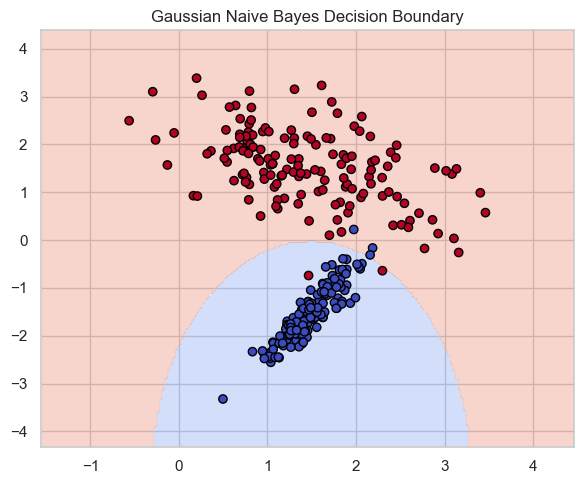

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx1, xx2, grid_preds, levels=2, cmap="coolwarm", alpha=0.3)
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", edgecolor="black")
ax.set_title("Gaussian Naive Bayes Decision Boundary")
plt.tight_layout()
plt.show()


## 7. The Zero-Frequency Problem

If a category never appears with a given class in training data, its estimated likelihood is exactly 0 — and since Naive Bayes *multiplies* likelihoods, that single zero wipes out the entire class score, no matter how strong the other evidence is.


In [20]:
# Simulate: a word that never appeared in the 'not spam' training examples
word_counts_spam = np.array([5, 3, 8, 0, 2])       # counts of a specific word across 5 spam emails
word_counts_not_spam = np.array([0, 0, 0, 0, 0])   # this word NEVER appeared in 'not spam' training emails


In [21]:
likelihood_given_not_spam = word_counts_not_spam.sum() / (word_counts_not_spam.sum() + 100)   # naive raw estimate
print(f"Raw P(word | not spam) estimate: {likelihood_given_not_spam}")
print("-> Exactly zero. If this word appears in a NEW email, P(not spam | word) becomes exactly zero too,")
print("   regardless of every other word in the email -- one unseen word can never be overridden by evidence.")


Raw P(word | not spam) estimate: 0.0
-> Exactly zero. If this word appears in a NEW email, P(not spam | word) becomes exactly zero too,
   regardless of every other word in the email -- one unseen word can never be overridden by evidence.


## 8. Laplace (Additive) Smoothing — the Fix

Adding a small constant $\alpha$ (typically 1) to every count before computing probabilities ensures no likelihood is ever exactly zero — full formula in the README. This is `MultinomialNB`'s `alpha` parameter, and it's on by default for good reason.


In [22]:
def laplace_smoothed_likelihood(count, total, n_categories, alpha=1):
    return (count + alpha) / (total + alpha * n_categories)


In [23]:
raw = 0 / 100
smoothed = laplace_smoothed_likelihood(count=0, total=100, n_categories=2, alpha=1)


In [24]:
print(f"Raw likelihood estimate (zero-frequency problem):  {raw}")
print(f"Laplace-smoothed likelihood estimate:               {smoothed:.4f}")
print("-> No longer exactly zero -- a single unseen category can be outweighed by strong evidence elsewhere.")


Raw likelihood estimate (zero-frequency problem):  0.0
Laplace-smoothed likelihood estimate:               0.0098
-> No longer exactly zero -- a single unseen category can be outweighed by strong evidence elsewhere.


## 9. Multinomial Naive Bayes — for Count Data

`MultinomialNB` models features as counts (word frequencies, event counts) rather than continuous Gaussians — the standard choice for text classification, where features are literally "how many times did word $j$ appear."


In [25]:
documents = [
    "win free money now",
    "claim your free prize today",
    "meeting scheduled for tomorrow",
    "please review the attached report",
    "free free free click now to win",
    "team lunch on friday afternoon",
    "urgent claim your reward now",
    "quarterly report attached for review",
]
labels = np.array([1, 1, 0, 0, 1, 0, 1, 0])   # 1 = spam, 0 = not spam


In [26]:
vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(documents)


In [27]:
print("Vocabulary:", vectorizer.get_feature_names_out())
print("\nDocument-term matrix shape:", X_counts.shape)
pd.DataFrame(X_counts.toarray(), columns=vectorizer.get_feature_names_out())


Vocabulary: ['afternoon' 'attached' 'claim' 'click' 'for' 'free' 'friday' 'lunch'
 'meeting' 'money' 'now' 'on' 'please' 'prize' 'quarterly' 'report'
 'review' 'reward' 'scheduled' 'team' 'the' 'to' 'today' 'tomorrow'
 'urgent' 'win' 'your']

Document-term matrix shape: (8, 27)


,afternoon,attached,claim,click,for,free,friday,lunch,meeting,money,...,reward,scheduled,team,the,to,today,tomorrow,urgent,win,your
0,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
1,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
2,0,0,0,0,1,0,0,0,1,0,...,0,1,0,0,0,0,1,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0,0,0,1,0,3,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
5,1,0,0,0,0,0,1,1,0,0,...,0,0,1,0,0,0,0,0,0,0
6,0,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,1
7,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 10. Training MultinomialNB on Text

With word counts as features, `MultinomialNB` learns per-word, per-class likelihoods (with Laplace smoothing baked in by default) — the classic spam-filter algorithm.


In [28]:
mnb = MultinomialNB(alpha=1.0)
mnb.fit(X_counts, labels)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[4.,4.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.69,-0.69]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 27)","[[1.,2.,0.,...,0.,0.,0.], [0.,0.,2.,...,1.,2.,2.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 27)","[[-3.14,-2.73,-3.83,...,-3.83,-3.83,-3.83], [-3.87,-3.87,-2.77,...,-3.18,-2.77,-2.77]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,27


In [29]:
test_docs = ["free prize waiting for you", "let's schedule the quarterly meeting"]
test_counts = vectorizer.transform(test_docs)
test_preds = mnb.predict(test_counts)
test_probs = mnb.predict_proba(test_counts)


In [30]:
for doc, pred, prob in zip(test_docs, test_preds, test_probs):
    label = "SPAM" if pred == 1 else "NOT SPAM"
    print(f'"{doc}" -> {label} (P(spam)={prob[1]:.3f})')


"free prize waiting for you" -> SPAM (P(spam)=0.779)
"let's schedule the quarterly meeting" -> NOT SPAM (P(spam)=0.099)


## 11. Bernoulli Naive Bayes — for Binary Features

`BernoulliNB` models features as binary presence/absence (not counts) — appropriate when "did this word appear at all" matters more than "how many times." It also explicitly penalizes the *absence* of a feature, unlike Multinomial, which only accumulates evidence from presence.


In [31]:
X_binary = (X_counts > 0).astype(int)   # convert counts to presence/absence
bnb = BernoulliNB(alpha=1.0)
bnb.fit(X_binary, labels)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[4.,4.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.69,-0.69]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 27)","[[1.,2.,0.,...,0.,0.,0.], [0.,0.,2.,...,1.,2.,2.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 27)","[[-1.1 ,-0.69,-1.79,...,-1.79,-1.79,-1.79], [-1.79,-1.79,-0.69,...,-1.1 ,-0.69,-0.69]]"


In [32]:
test_binary = (test_counts > 0).astype(int)
bnb_preds = bnb.predict(test_binary)
bnb_probs = bnb.predict_proba(test_binary)


In [33]:
for doc, pred, prob in zip(test_docs, bnb_preds, bnb_probs):
    label = "SPAM" if pred == 1 else "NOT SPAM"
    print(f'"{doc}" -> {label} (P(spam)={prob[1]:.3f})')


"free prize waiting for you" -> SPAM (P(spam)=0.765)
"let's schedule the quarterly meeting" -> NOT SPAM (P(spam)=0.040)


In [34]:
print("\nMultinomialNB and BernoulliNB agree here, but can diverge on longer documents")
print("where word REPETITION carries real signal (Multinomial captures it, Bernoulli ignores it).")



MultinomialNB and BernoulliNB agree here, but can diverge on longer documents
where word REPETITION carries real signal (Multinomial captures it, Bernoulli ignores it).


## 12. Comparing the Three Variants — Which Fits Which Data

Using the *wrong* NB variant for a given feature type (e.g. GaussianNB on raw word counts) produces a mismatched, poorly-calibrated model — the likelihood formula must match how the features are actually distributed.


In [35]:
variant_table = pd.DataFrame({
    "Variant": ["GaussianNB", "MultinomialNB", "BernoulliNB"],
    "Feature type": ["Continuous (real-valued)", "Counts (non-negative integers)", "Binary (0/1)"],
    "Typical use case": ["Sensor readings, measurements", "Word counts, event frequencies", "Word presence, binary flags"],
    "Likelihood model": ["Gaussian PDF per feature", "Multinomial distribution", "Bernoulli distribution per feature"],
})
variant_table


,Variant,Feature type,Typical use case,Likelihood model
0,GaussianNB,Continuous (real-valued),"Sensor readings, measurements",Gaussian PDF per feature
1,MultinomialNB,Counts (non-negative integers),"Word counts, event frequencies",Multinomial distribution
2,BernoulliNB,Binary (0/1),"Word presence, binary flags",Bernoulli distribution per feature


## 13. Real Dataset — Wine Classification with GaussianNB

Applying GaussianNB to the real Wine dataset (13 continuous chemical-measurement features, 3 classes) — the ideal feature type for this variant.


In [36]:
wine = load_wine(as_frame=True)
X_wine, y_wine = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(X_wine, y_wine, test_size=0.2, stratify=y_wine, random_state=42)


In [37]:
wine_gnb = GaussianNB()
wine_gnb.fit(X_train, y_train)
wine_preds = wine_gnb.predict(X_test)


In [38]:
print(f"Test accuracy: {accuracy_score(y_test, wine_preds):.4f}")
print("\n", classification_report(y_test, wine_preds, target_names=wine.target_names))


Test accuracy: 0.9722

               precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



## 14. Confusion Matrix — Wine Dataset


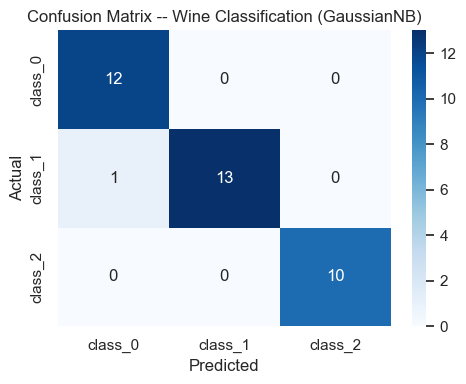

In [39]:
cm = confusion_matrix(y_test, wine_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=wine.target_names, yticklabels=wine.target_names)
ax.set_title("Confusion Matrix -- Wine Classification (GaussianNB)")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


## 15. Effect of the Independence Violation

Building on section 2's correlated features: does the naive assumption actually hurt accuracy when features are strongly correlated? We compare GaussianNB's performance on independent vs. artificially-correlated versions of the same underlying signal.


In [40]:
np.random.seed(2)
n = 500
true_signal = np.random.normal(0, 1, n)
class_label = (true_signal > 0).astype(int)


In [41]:
# Independent case: two unrelated noisy views of the signal
X_independent = np.column_stack([
    true_signal + np.random.normal(0, 0.5, n),
    np.random.normal(0, 1, n) + class_label * 0.8,   # separate, independent signal
])


In [42]:
# Correlated case: second feature is mostly a copy of the first (violates the naive assumption)
X_correlated = np.column_stack([
    true_signal + np.random.normal(0, 0.5, n),
    true_signal + np.random.normal(0, 0.5, n),   # near-duplicate of feature 1
])


In [43]:
acc_independent = cross_val_score(GaussianNB(), X_independent, class_label, cv=5).mean()
acc_correlated = cross_val_score(GaussianNB(), X_correlated, class_label, cv=5).mean()


In [44]:
print(f"GaussianNB CV accuracy, independent features: {acc_independent:.4f}")
print(f"GaussianNB CV accuracy, correlated features:  {acc_correlated:.4f}")
print("\n-> Correlated features effectively 'double-count' the same evidence (since NB multiplies")
print("   per-feature likelihoods as if independent), which can overstate confidence without necessarily")
print("   changing the final predicted class -- accuracy often survives better than calibration does.")


GaussianNB CV accuracy, independent features: 0.8880
GaussianNB CV accuracy, correlated features:  0.8760

-> Correlated features effectively 'double-count' the same evidence (since NB multiplies
   per-feature likelihoods as if independent), which can overstate confidence without necessarily
   changing the final predicted class -- accuracy often survives better than calibration does.


## 16. Naive Bayes vs Logistic Regression

Both are simple, fast baseline classifiers, but built from opposite philosophies: Naive Bayes is **generative** (models how the data was generated, $P(x \mid y)$, then inverts via Bayes' theorem), Logistic Regression is **discriminative** (models the decision boundary, $P(y \mid x)$, directly). Comparing them on the same data highlights when each philosophy wins.


In [45]:
nb_model = GaussianNB().fit(X_train, y_train)
lr_model = LogisticRegression(max_iter=5000).fit(X_train, y_train)


In [46]:
nb_acc = accuracy_score(y_test, nb_model.predict(X_test))
lr_acc = accuracy_score(y_test, lr_model.predict(X_test))


In [47]:
print(f"GaussianNB test accuracy:         {nb_acc:.4f}")
print(f"Logistic Regression test accuracy: {lr_acc:.4f}")
print("\n-> Both are strong baselines here. Naive Bayes trains near-instantly (closed-form parameter")
print("   estimates, no gradient descent needed) and often wins on small datasets or heavily categorical")
print("   data; Logistic Regression tends to win when features are genuinely correlated (its discriminative")
print("   approach doesn't assume independence at all).")


GaussianNB test accuracy:         0.9722
Logistic Regression test accuracy: 0.9444

-> Both are strong baselines here. Naive Bayes trains near-instantly (closed-form parameter
   estimates, no gradient descent needed) and often wins on small datasets or heavily categorical
   data; Logistic Regression tends to win when features are genuinely correlated (its discriminative
   approach doesn't assume independence at all).


## ✅ Key Takeaways

- Naive Bayes is the Math Refresher's Bayes' theorem, applied literally: prior × likelihood / evidence, computed per class, per prediction.
- The "naive" independence assumption is almost always technically wrong, but the algorithm often still works well — it needs the *ranking* of class scores to be right, not the exact probability values.
- Match the NB variant to the feature type: **Gaussian** for continuous, **Multinomial** for counts, **Bernoulli** for binary presence/absence — using the wrong one silently degrades the model.
- **Laplace smoothing is not optional** for count/binary data — without it, a single unseen category zeroes out an entire class's probability regardless of all other evidence.
- Naive Bayes trains almost instantly (closed-form estimates, no iterative optimization) — a genuinely different cost profile from every gradient-based model in this series.
- As a **generative** model, Naive Bayes models $P(x \mid y)$ and inverts it; Logistic Regression's **discriminative** approach models $P(y \mid x)$ directly — this distinction resurfaces conceptually with LDA/QDA, later in this category.

**Next up:** [04_Decision_Tree_Classifier](../04_Decision_Tree_Classifier/) — a rule-based, fully interpretable approach with no probability model at all.
